In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_auc_score)

In [4]:
df=pd.read_csv("Cleaned_Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Observation

The cleaned customer churn dataset was successfully loaded into the notebook. Initial records were examined to understand the structure, columns, and overall quality of the data before performing further analysis.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
df = df.fillna(df.median(numeric_only=True))

### Observation

The dataset was examined for missing values to ensure data quality. Missing values can negatively impact machine learning performance, so identifying and handling them is an important preprocessing step.

In [10]:
df.drop_duplicates(inplace=True)

### Observation

Duplicate records were removed from the dataset to avoid bias and ensure accurate model training. Removing duplicates improves the reliability of the analysis.

In [11]:
df.shape

(7043, 21)

In [12]:
le=LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col]=le.fit_transform(df[col])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


### Observation
- Categorical variables were converted into numerical values.
- Dataset became compatible with machine learning algorithms.

In [13]:
df['Avg_Revenue_Per_Month']=df['MonthlyCharges']
df['Customer_Age_Group']=pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['New','Regular','Loyal','VIP']
)

### Observation
- New business-oriented features were created.
- Customer groups were formed based on tenure.

In [14]:
df['Customer_Age_Group']=LabelEncoder().fit_transform(
    df['Customer_Age_Group']
)

### Observation 
- Newly created categorical feature was encoded.
- Data became ready for model training.

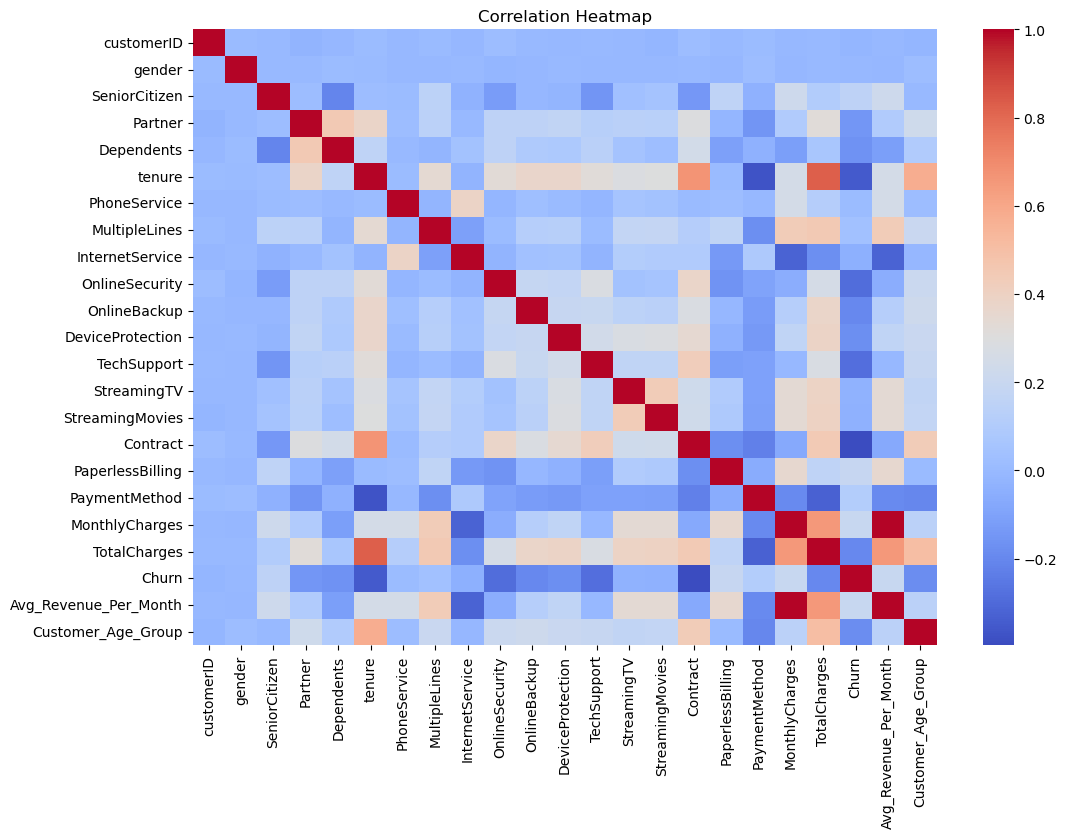

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observation
- Relationships among variables were analyzed.
- Highly cirrelated features were identified.

In [16]:
X=df.drop('Churn',axis=1)
y=df['Churn']

### Observation
- Independent variables and target variable were separated.
- Churn was selected as the prediction target.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Observation
- Dataset was divided into training and testing sets.
- 80% training and 20% testing ratio was used.

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Observation
- Features were standardized.
- Scaling improves model performance and stability.

In [19]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [23]:
print(accuracy_score(y_test,lr_pred))

0.8161816891412349


### Observation
- Logistic Regression was trained as baseline model.
- Initial churn prediction performance was evaluated.

In [29]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
dt_pred=dt.predict(X_test)

In [30]:
print(accuracy_score(y_test,dt_pred))

0.7274662881476224


### Observation
- Decision Tree model was trained.
- Non-linear customer behaviour patterns were captured.

In [24]:
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

In [48]:
print(accuracy_score(y_test,rf_pred))

0.7906316536550745


### Observation
- Random Forest was trained using multiple decision trees.
- Typically provides better predictive performance.

In [31]:
print("Logistic Regression:",accuracy_score(y_test,lr_pred))
print("Decision Tree:",accuracy_score(y_test,dt_pred))
print("Random Forest:",accuracy_score(y_test,rf_pred))

Logistic Regression: 0.8161816891412349
Decision Tree: 0.7274662881476224
Random Forest: 0.7906316536550745


### Observation 
- Performance of multiple models was compared.
- Best model was selected based on accuracy.

In [32]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1036
           1       0.64      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



### Observation
- Precision,Recall and F1-score were evaluated.
- Detailed model performance metrices were obtained.

In [33]:
cm=confusion_matrix(y_test,rf_pred)
print(cm)

[[938  98]
 [197 176]]


### Observation
- Correct and incorrect predictions were analyzed.
- Model strengths and weakness were identified.

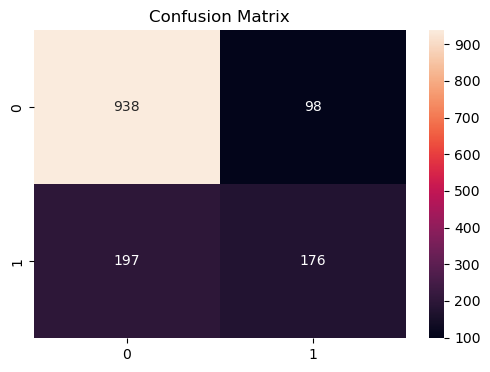

In [34]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Observation
- Visualization simplified model evaluation.
- Prediction accuracy was clearly represented.

In [35]:
prob=rf.predict_proba(X_test)[:,1]
auc=roc_auc_score(y_test,prob)
print(auc)

0.8414051259225522


### Observation
- ROC-AUc measured model discrimination ability.
- Higher values indicate better classification performance.

In [36]:
importance=pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_})
importance=importance.sort_values(by='Importance',ascending=False)
importance.head(15)

,Feature,Importance
19,TotalCharges,0.132172
5,tenure,0.118634
18,MonthlyCharges,0.116044
20,Avg_Revenue_Per_Month,0.113261
0,customerID,0.110842
15,Contract,0.071356
9,OnlineSecurity,0.041434
17,PaymentMethod,0.038791
12,TechSupport,0.031269
21,Customer_Age_Group,0.028911


### Observation
- Key churn-driving features were identified.
- Important factors affecting customer retention were discovered.

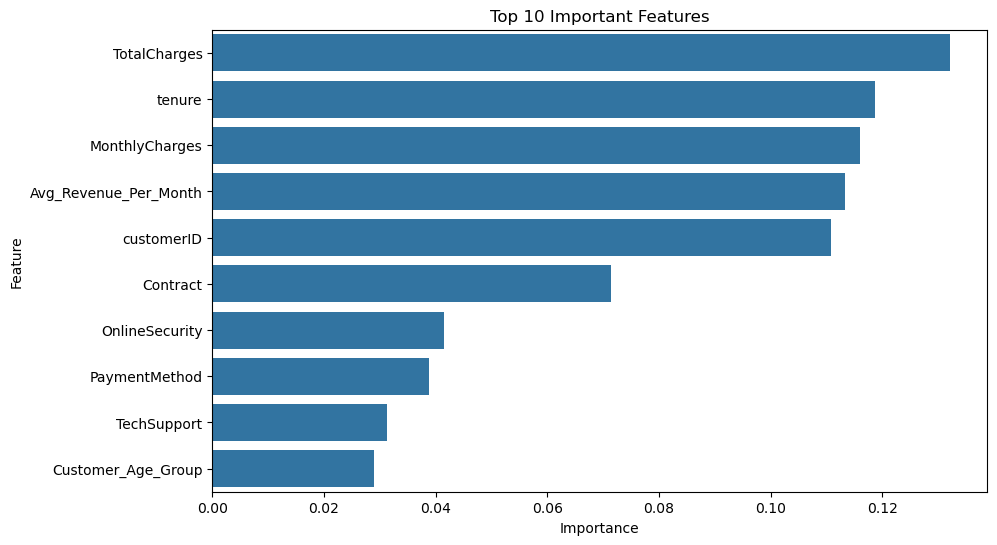

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance",y="Feature",data=importance.head(10))
plt.title("Top 10 Important Features")
plt.show()

### Observation
- Most influential variables were visualized.
- Helps businesses focus on critical retention factors.

In [38]:
df["Customer_Segment"]=pd.cut(df['MonthlyCharges'],bins=[0,35,70,120],labels=['Low Value','Medium Value','High Value'])

### Observation
- Customers were grouped according to monthly revenue contribution.
- Segmentation supports targeted marketing strategies.

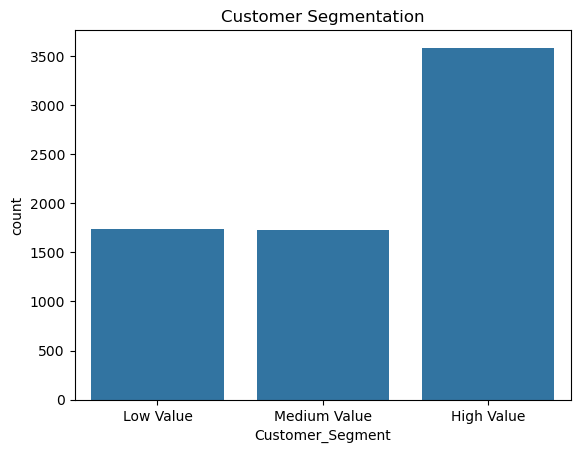

In [39]:
sns.countplot(x='Customer_Segment',data=df)
plt.title("Customer Segmentation")
plt.show()

### Observation
- Distribution of customer segments was visualized.
- Revenue-generating customer groups were identified.

In [40]:
df['LTV']=(df['MonthlyCharges']*df['tenure'])
df[['MonthlyCharges','tenure','LTV']].head()

,MonthlyCharges,tenure,LTV
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


### Observation
- Customer Lifetime Value was estimated.
- Long-term customer revenue contribution was measured.

In [43]:
df['LTV'].describe()

count    7043.000000
mean     2279.581350
std      2264.729447
min         0.000000
25%       394.000000
50%      1393.600000
75%      3786.100000
max      8550.000000
Name: LTV, dtype: float64

### Observation
- Summary statistics of customer value were obtained.
- High-value customers were identified.


In [44]:
df['LTV_Segment']=pd.qcut(df['LTV'],q=4,labels=['Bronze','Silver','Gold','Platinum'])

### Observation
- Customers were divided into four value categories.
- Supports retention and loyalty program planning.

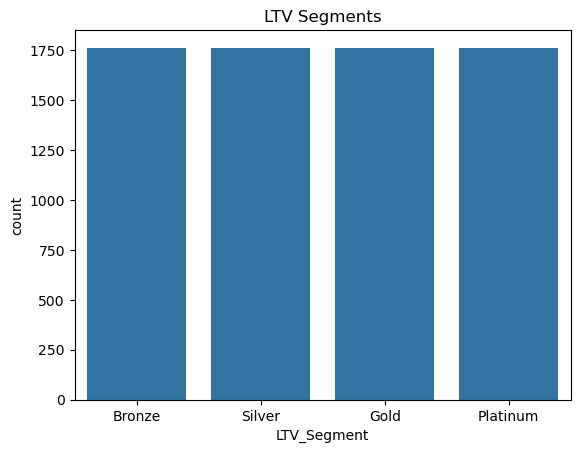

In [45]:
sns.countplot(x='LTV_Segment',data=df)
plt.title("LTV Segments")
plt.show()

### Observation
- Distribution of customer lifetime value groups was analyzed.
- Valuable customers were easily identified.

| Churn Risk | LTV Category | Recommended Action  |
| ---------- | ------------ | ------------------- |
| High       | Platinum     | Immediate Retention |
| High       | Gold         | Special Offers      |
| Medium     | Silver       | Loyalty Program     |
| Low        | Bronze       | Regular Monitoring  |


### Observation
- Business strategies were mapped to customer value.
- High-value customers can be priortized for retention.

In [47]:
df.to_csv("customer_churn_ltv_final.csv",index=False)

### Observation 
- Final processed dataset was exported successfully.
- Dataset is ready for deployment and future analysis.